# Midpoint Rule (Single & Composite)
Instead of drawing lines connecting the edges of the panels, we just look at the exact middle of the panel, and draw a flat rectangle at that height.
It seems dumb and simple, but it is actually highly effective, and completely sidesteps issues where the function might crash or divide by zero at the exact edges of the interval!

### The Math
For a single panel of width $h = b - a$ with midpoint $m = \frac{a+b}{2}$:
$$ \text{Area} = h \cdot f(m) $$

For the Composite Midpoint Rule with $n$ panels of width $h$:
$$ \int_a^b f(x) dx \approx h \sum_{i=1}^{n} f(m_i) $$
where $m_i$ are the exact midpoints of each panel.

In [1]:
import numpy as np

def f(x):
    return x**2

def midpoint_single(f, a, b):
    midpoint = (a + b) / 2
    h = b - a
    area = h * f(midpoint)
    return area

def midpoint_composite(f, a, b, num_panels):
    h = (b - a) / num_panels
    
    # Get the exact midpoints of every single panel
    midpoints = np.linspace(a + h/2, b - h/2, num_panels)
    
    # We just sum the height of all the rectangles and multiply by width
    area = h * np.sum(f(midpoints))
    return area

# Example usage
print("Single Midpoint Area:", midpoint_single(f, 0, 1))
print("Composite Midpoint Area (100 panels):", midpoint_composite(f, 0, 1, 100))


Single Midpoint Area: 0.25
Composite Midpoint Area (100 panels): 0.33332500000000004


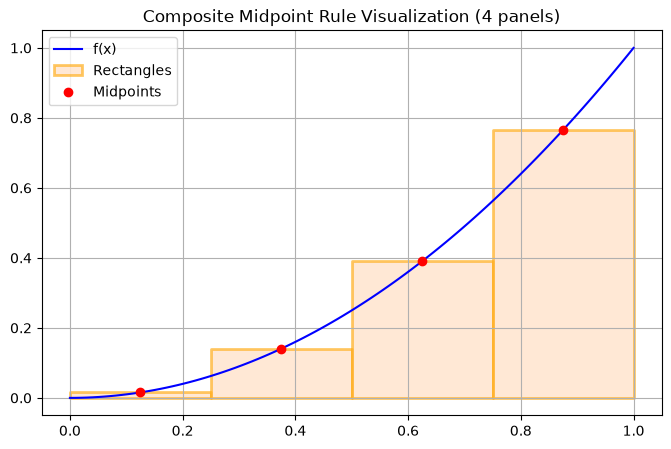

In [2]:
import matplotlib.pyplot as plt
import numpy as np
x_fine = np.linspace(0, 1, 100)
y_fine = f(x_fine)
n = 4
x_edges = np.linspace(0, 1, n+1)
x_mids = (x_edges[:-1] + x_edges[1:])/2
y_mids = f(x_mids)
plt.figure(figsize=(8, 5))
plt.plot(x_fine, y_fine, 'b-', label='f(x)')
for i in range(n):
    plt.fill_between([x_edges[i], x_edges[i+1]], 0, [y_mids[i], y_mids[i]], color='peachpuff', alpha=0.6, edgecolor='orange', linewidth=2, label='Rectangles' if i==0 else '')
plt.plot(x_mids, y_mids, 'ro', label='Midpoints')
plt.title('Composite Midpoint Rule Visualization (4 panels)')
plt.legend()
plt.grid(True)
plt.show()
